# Final Composite Ensemble + Diagnostics + Explainability — LendingClub Interest Rate Prediction

This notebook combines two things:

1. The **six-base-learner stacked ensemble** (XGBoost, LightGBM, CatBoost,
   RandomForest, Ridge, MLP → Ridge stacker / hill-climb blend), **loaded from the
   cached artifacts** in `outputs/final/` that `final/final_pipeline.py` produces.
2. The full **diagnostic** and **explainability** suites ported from
   `1FINAL_SIMPLIFIED_MIN_RMSE_V2.ipynb`, **computed live** when you run the notebook.

**Part 1 — Cached ensemble**
Loads the base learners + meta-blend and reports held-out RMSE, the model-comparison
chart, residual diagnostics, and the submission file.

**Part 2 — Diagnostic suite (live)**
1. Per-base-learner learning curves over boosting rounds (fold-0 GBDTs)
2. sklearn `learning_curve` on CatBoost over training-set size
3. OOF-vs-validation residual distribution overlay
4. Per-fold OOF RMSE bar chart (reconstructed from the cached OOF predictions)

**Part 3 — Explainability (live, W2 style)**
Permutation importance, CatBoost native gain, SHAP summary / dependence, PDP / ICE,
SHAP waterfall, LIME, and cross-split SHAP — all on a single CatBoost refit on the
full 80% training fold.

**Anti-leakage** (inherited from the pipeline)
- `loan_status` dropped (post-origination outcome)
- Random 80/20 holdout (no date columns in this slice — temporal split impossible)
- K-fold OOF smoothed target encoding for high-cardinality categoricals
- All preprocessing fit on training folds only

> **Prerequisite:** `outputs/final/ensemble_artifacts.pkl` and
> `outputs/sota/tuning_results.json` must exist. Regenerate with
> `.venv/Scripts/python.exe final/final_pipeline.py`.


---
# Part 1 — Cached ensemble

## 1. Imports + paths

In [24]:
from pathlib import Path
import sys, json, warnings, pickle
from time import time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split, learning_curve
from sklearn.linear_model import Ridge

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'final':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'final'))

# Share one source of truth with the pipeline module.
import final_pipeline as fp

OUT_DIR = fp.OUTPUTS_DIR
print('Project root:', PROJECT_ROOT)
print('Data dir    :', fp.DATA_DIR)
print('Outputs dir :', OUT_DIR)


Project root: c:\Users\liula\Documents\applied ai\project 1
Data dir    : C:\Users\liula\Documents\applied ai\project 1\true data
Outputs dir : C:\Users\liula\Documents\applied ai\project 1\outputs\final


## 2. Load + drop leakage column

`loan_status` is a post-origination outcome and would leak future information into a
rate model, so the pipeline drops it on load. `ID` is held aside for the submission.

In [25]:
train_raw, test_raw = fp.load_raw()
print('train:', train_raw.shape, '   test:', test_raw.shape)
print('target stats:')
print(train_raw['int_rate'].describe().round(3))


train: (100000, 38)    test: (10000, 38)
target stats:
count    100000.000
mean         12.947
std           5.256
min           6.460
25%           8.190
50%          11.710
75%          16.120
max          30.990
Name: int_rate, dtype: float64


## 3. Feature engineering

Stateless transforms only (FICO midpoint + band, term, underwriting ratios,
interactions, log-tails, `zip3`, missingness flags). Anything that needs a fit
(target encoding, imputation) happens inside the K-fold loop in the pipeline.

In [26]:
train_fe = fp.engineer(train_raw)
test_fe  = fp.engineer(test_raw)

# Top-N emp_title compaction (fit on train only) — must match the pipeline.
top = train_fe['emp_title'].value_counts().head(fp.EMP_TITLE_TOP_N).index.tolist()
train_fe['emp_title'] = train_fe['emp_title'].where(train_fe['emp_title'].isin(top), 'Other').fillna('Missing').astype(str)
test_fe['emp_title']  = test_fe['emp_title'].where(test_fe['emp_title'].isin(top), 'Other').fillna('Missing').astype(str)

test_ids = test_fe['ID'].copy()
test_fe = test_fe.drop(columns=['ID'])

y_full = train_fe['int_rate'].values.astype(np.float64)
X_full = train_fe.drop(columns=['int_rate'])
print('engineered cols:', X_full.shape[1])
print(list(X_full.columns))


engineered cols: 60
['addr_state', 'all_util', 'annual_inc', 'application_type', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'emp_title', 'home_ownership', 'inq_fi', 'inq_last_12m', 'loan_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mort_acc', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc', 'mths_since_recent_inq', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util', 'tot_coll_amt', 'tot_cur_bal', 'total_acc', 'total_bal_ex_mort', 'verification_status', 'fico', 'term_months', 'emp_length_num', 'has_mths_since_last_record', 'has_mths_since_recent_inq', 'has_mths_since_rcnt_il', 'has_mths_since_recent_bc', 'loan_to_income', 'installment_proxy', 'bal_to_income', 'util_x_fico', 'dti_x_fico', 'acc_open_ratio', 'dti_band', 'fico_band', 'derog_score', 'inq_intensity', 'revol_util_band', 'all_util_band', 'credit_file_age_yrs', 'term_x_loan_amnt', 'term_x_dti', 'payment_to_income', 'log1p_annual

## 4. 80/20 holdout split

Fixed-seed random split (`fp.RANDOM_STATE`, `fp.HOLDOUT_FRAC`) — the same split the
pipeline used, so the cached prediction stacks line up positionally with `X_train` /
`X_val` here.

In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=fp.HOLDOUT_FRAC, random_state=fp.RANDOM_STATE,
)
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
print('X_train:', X_train.shape, '  X_val:', X_val.shape, '  X_test:', test_fe.shape)


X_train: (80000, 60)   X_val: (20000, 60)   X_test: (10000, 60)


## 5. Cached Optuna tuning params

The GBDT hyperparameters used by the pipeline and reused for the live diagnostics /
explainability below.

In [28]:
tuning = json.loads(fp.CACHED_TUNING.read_text())['params']
for name, p in tuning.items():
    print('[' + name + ']', p)


[CatBoost] {'learning_rate': 0.03, 'depth': 7, 'l2_leaf_reg': 5.0, 'random_strength': 1.0, 'bagging_temperature': 0.5, 'border_count': 200}
[LightGBM] {'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 60, 'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 1, 'reg_alpha': 0.1, 'reg_lambda': 0.5}
[XGBoost] {'learning_rate': 0.03, 'max_depth': 6, 'min_child_weight': 20, 'subsample': 0.8, 'colsample_bytree': 0.8, 'colsample_bylevel': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'gamma': 0.1}


## 6. Load cached ensemble artifacts

Loads the per-base out-of-fold / validation / test prediction stacks, the Ridge-stacker
coefficients, and the hill-climb weights from `ensemble_artifacts.pkl`, then asserts the
cached split matches this notebook's split.

In [29]:
ART = OUT_DIR / 'ensemble_artifacts.pkl'
if not ART.exists():
    raise FileNotFoundError('Missing ' + str(ART) + '. Regenerate with: .venv/Scripts/python.exe final/final_pipeline.py')

with open(ART, 'rb') as fh:
    art = pickle.load(fh)
BASES = art['BASES']
stack_tr = art['oof_stack']
stack_va = art['val_stack']
stack_te = art['test_stack']
stacker_coef = art['stacker_coef']
stacker_alpha = art['stacker_alpha']
stacker_intercept = art['stacker_intercept']
hc_w = np.array(art['hill_climb_weights'])
chosen = art['chosen_blend']
y_train_saved = art['y_train']
y_val_saved = art['y_val']

# The notebook's split must match the pipeline's cached arrays positionally.
assert np.allclose(y_train, y_train_saved), 'y_train mismatch - re-run final_pipeline.py'
assert np.allclose(y_val, y_val_saved), 'y_val mismatch - re-run final_pipeline.py'
assert stack_tr.shape[0] == len(X_train) and stack_va.shape[0] == len(X_val)

print('Artifacts aligned with notebook split.')
print('bases             :', BASES)
print('chosen blend      :', chosen)
print('stacker alpha     :', stacker_alpha)
print('stacker weights   :', dict(zip(BASES, np.round(stacker_coef, 3))))
print('hill-climb weights:', dict(zip(BASES, np.round(hc_w, 3))))


Artifacts aligned with notebook split.
bases             : ['cb', 'lgb', 'xgb', 'rf', 'ridge', 'mlp']
chosen blend      : Ridge stack
stacker alpha     : 100.0
stacker weights   : {'cb': np.float64(0.953), 'lgb': np.float64(0.0), 'xgb': np.float64(0.054), 'rf': np.float64(0.0), 'ridge': np.float64(0.0), 'mlp': np.float64(0.011)}
hill-climb weights: {'cb': np.float64(0.972), 'lgb': np.float64(0.016), 'xgb': np.float64(0.0), 'rf': np.float64(0.0), 'ridge': np.float64(0.0), 'mlp': np.float64(0.012)}


## 7. Chosen-blend predictions (OOF / val / test)

Rebuilds the winning meta-blend (Ridge stack or hill-climb) from the cached stacks.

In [30]:
if chosen == 'Ridge stack':
    stacker = Ridge(alpha=stacker_alpha, positive=True).fit(stack_tr, y_train)
    oof_blend  = stacker.predict(stack_tr)
    val_blend  = stacker.predict(stack_va)
    test_blend = stacker.predict(stack_te)
else:
    oof_blend  = stack_tr @ hc_w
    val_blend  = stack_va @ hc_w
    test_blend = stack_te @ hc_w

print('Chosen blend:', chosen)
print('  OOF RMSE: %.4f' % np.sqrt(mean_squared_error(y_train, oof_blend)))
print('  val RMSE: %.4f' % np.sqrt(mean_squared_error(y_val, val_blend)))


Chosen blend: Ridge stack
  OOF RMSE: 3.8630
  val RMSE: 3.8730


## 8. Per-base-learner + blend held-out RMSE

In [31]:
rows = []
for i, b in enumerate(BASES):
    rows.append({'model': b.upper(),
                 'OOF_RMSE': float(np.sqrt(mean_squared_error(y_train, stack_tr[:, i]))),
                 'val_RMSE': float(np.sqrt(mean_squared_error(y_val, stack_va[:, i]))),
                 'val_MAE':  float(mean_absolute_error(y_val, stack_va[:, i])),
                 'val_R2':   float(r2_score(y_val, stack_va[:, i]))})
rows.append({'model': chosen,
             'OOF_RMSE': float(np.sqrt(mean_squared_error(y_train, oof_blend))),
             'val_RMSE': float(np.sqrt(mean_squared_error(y_val, val_blend))),
             'val_MAE':  float(mean_absolute_error(y_val, val_blend)),
             'val_R2':   float(r2_score(y_val, val_blend))})
res_df = pd.DataFrame(rows).sort_values('val_RMSE').reset_index(drop=True)
display(res_df.style.format({'OOF_RMSE': '{:.4f}', 'val_RMSE': '{:.4f}', 'val_MAE': '{:.4f}', 'val_R2': '{:.4f}'}))


,model,OOF_RMSE,val_RMSE,val_MAE,val_R2
0,Ridge stack,3.8630,3.8730,2.8993,0.4645
1,CB,3.8634,3.8734,2.9030,0.4644
2,XGB,3.9533,3.9620,2.9734,0.4396
3,MLP,5.2124,3.9628,2.9790,0.4394
4,LGB,3.9734,3.9708,2.9817,0.4371
5,RF,4.0371,4.0682,3.0694,0.4091
6,RIDGE,4.6499,4.2115,3.2439,0.3668


## 9. Model comparison chart

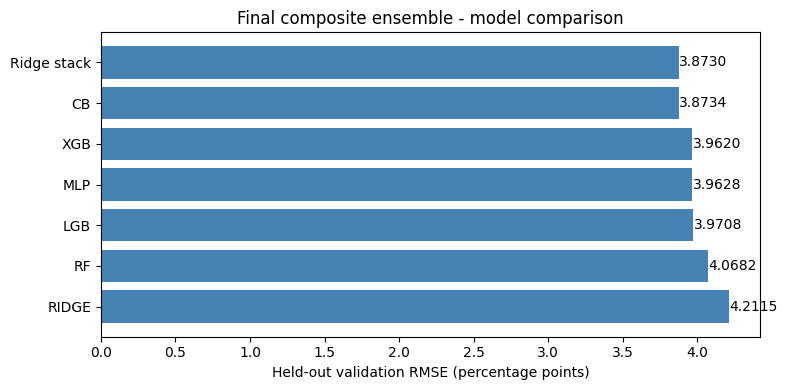

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(res_df['model'], res_df['val_RMSE'], color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Held-out validation RMSE (percentage points)')
ax.set_title('Final composite ensemble - model comparison')
for i, v in enumerate(res_df['val_RMSE']):
    ax.text(v + 0.005, i, '%.4f' % v, va='center')
plt.tight_layout()
plt.savefig(OUT_DIR / 'final_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Residual diagnostics for the chosen blend

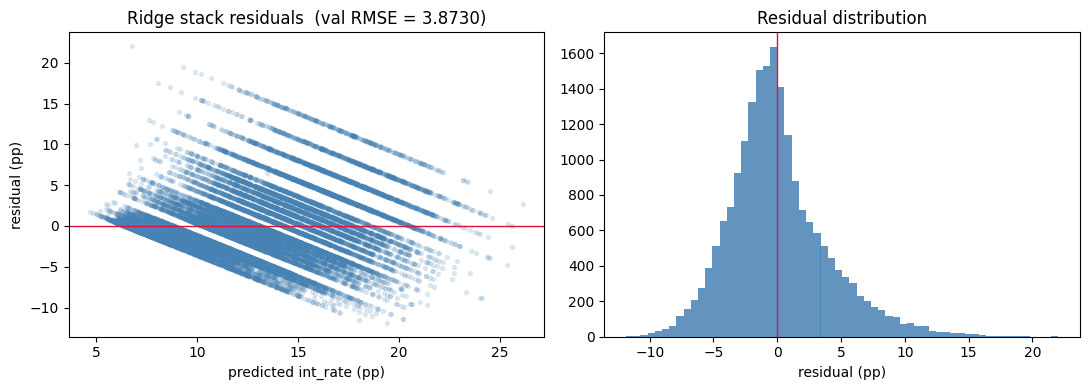

In [33]:
resid = y_val - val_blend
rmse = float(np.sqrt(mean_squared_error(y_val, val_blend)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(val_blend, resid, alpha=0.15, s=8, color='steelblue')
axes[0].axhline(0, color='crimson', lw=1)
axes[0].set_xlabel('predicted int_rate (pp)')
axes[0].set_ylabel('residual (pp)')
axes[0].set_title(chosen + ' residuals  (val RMSE = %.4f)' % rmse)
axes[1].hist(resid, bins=60, color='steelblue', alpha=0.85)
axes[1].axvline(0, color='crimson', lw=1)
axes[1].set_xlabel('residual (pp)')
axes[1].set_title('Residual distribution')
plt.tight_layout()
plt.savefig(OUT_DIR / 'final_residuals.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Test-set predictions

Predictions are clipped to `[6.0, 31.0]` (observed `int_rate` range in train) and
written with the required `ID, int_rate` schema.

In [34]:
final_test = np.clip(test_blend, 6.0, 31.0)
sub = pd.DataFrame({'ID': test_ids.values, 'int_rate': final_test})
sub_path = OUT_DIR / 'final_test_predictions.csv'
sub.to_csv(sub_path, index=False)
print('Saved %d predictions -> %s' % (len(sub), sub_path))
print()
print('int_rate distribution:')
print(sub['int_rate'].describe().round(3))
display(sub.head(10))


Saved 10000 predictions -> C:\Users\liula\Documents\applied ai\project 1\outputs\final\final_test_predictions.csv

int_rate distribution:
count    10000.000
mean        11.941
std          3.350
min          6.000
25%          9.337
50%         11.821
75%         14.346
max         23.354
Name: int_rate, dtype: float64


,ID,int_rate
0,1,13.124367
1,2,14.735264
2,3,8.589253
3,4,15.622385
4,5,16.555374
5,6,6.646703
6,7,12.341039
7,8,8.761760
8,9,14.260081
9,10,20.000097


---
# Part 2 — Diagnostic Suite (run live)

Four plots designed to tell you at a glance whether each base learner is over-, under-,
or well-fit, and whether the blend would benefit from more data or more capacity.

## Plot 1 — Per-base-learner learning curves over boosting rounds

For each tree-based learner: train RMSE and val RMSE plotted against iteration index
(fold-0 only, log-x grid). The fold-0 GBDTs are **refit live** here (the cached pipeline
does not store per-round curves). RandomForest / Ridge / MLP are not boosting learners,
so they have no per-round curve.

The dashed vertical line marks each learner's **best iteration** (the round with the
lowest val RMSE — i.e. where early stopping rolls the deployed model back to). The badge
reports the val-train gap **at that iteration**, not at the right edge, so it reflects the
model actually used rather than the patience tail of extra rounds past the best.

Reading guide (standard GBDT practice):
* **Large persistent gap, both still falling** → underfit on val. Reduce capacity, raise regularisation, or add data.
* **Small gap at the best-iteration line** → well-fit at the early-stopping point.
* **Train still falling, val rising past the line** → late-stage overfit; the patience tail the model discards.
* **Train and val identical and high** → severe underfit; raise depth or reduce regularisation.

In [35]:
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor, early_stopping as lgb_es, log_evaluation as lgb_log
from xgboost import XGBRegressor

# Diagnostic runtime knob (raise for longer / smoother curves).
LC_CB_ITERS = 600

learning_curves = {b: {'iters': [], 'train_rmse': [], 'val_rmse': []} for b in BASES}

kf = KFold(n_splits=fp.N_FOLDS, shuffle=True, random_state=fp.RANDOM_STATE)
tr_idx, va_idx = next(iter(kf.split(X_train)))
Xtr0, Xva0 = X_train.iloc[tr_idx], X_train.iloc[va_idx]
ytr0, yva0 = y_train[tr_idx], y_train[va_idx]
Xtr0_te, Xva0_te, _ = fp.add_target_encodings(Xtr0, ytr0, Xva0, test_fe)


def _sample_idx(n):
    s = np.unique(np.round(np.geomspace(5, n, 40)).astype(int)) - 1
    return s[s < n]


def _curve_entry(trc, vac):
    # best_pos = round with lowest val RMSE (val-monitored early-stop point).
    si = _sample_idx(len(vac))
    best_pos = int(np.argmin(vac))
    return {'iters': si.tolist(), 'train_rmse': trc[si].tolist(),
            'val_rmse': vac[si].tolist(), 'best_pos': best_pos,
            'best_train': float(trc[best_pos]), 'best_val': float(vac[best_pos])}


# --- CatBoost ---
t = time()
Xtr0_cb, cat_idx0 = fp.to_catboost_pool(Xtr0_te)
Xva0_cb, _ = fp.to_catboost_pool(Xva0_te)
cb_lc = CatBoostRegressor(**tuning['CatBoost'], iterations=LC_CB_ITERS, loss_function='RMSE',
                          eval_metric='RMSE', random_seed=fp.RANDOM_STATE, verbose=0,
                          allow_writing_files=False)
cb_lc.fit(Xtr0_cb, ytr0, cat_features=cat_idx0, eval_set=(Xva0_cb, yva0), verbose=False)
ev = cb_lc.get_evals_result()
trc, vac = np.array(ev['learn']['RMSE']), np.array(ev['validation']['RMSE'])
learning_curves['cb'] = _curve_entry(trc, vac)
print('  cb curve captured (%.0fs)' % (time() - t))

# --- LightGBM ---
t = time()
cat_dt = fp.build_cat_dtypes(Xtr0_te)
Xtr0_lgb, lgb_cat = fp.to_lgb_frame(Xtr0_te, cat_dt)
Xva0_lgb, _ = fp.to_lgb_frame(Xva0_te, cat_dt)
lgb_lc = LGBMRegressor(**tuning['LightGBM'], n_estimators=2000, objective='regression',
                       metric='rmse', random_state=fp.RANDOM_STATE, verbose=-1, n_jobs=-1)
lgb_lc.fit(Xtr0_lgb, ytr0, eval_set=[(Xtr0_lgb, ytr0), (Xva0_lgb, yva0)],
           eval_names=['train', 'val'], categorical_feature=lgb_cat,
           callbacks=[lgb_es(120, verbose=False), lgb_log(0)])
ev = lgb_lc.evals_result_ or {}
trc = np.array(ev.get('train', {}).get('rmse', []))
vac = np.array(ev.get('val', {}).get('rmse', []))
if len(vac):
    learning_curves['lgb'] = _curve_entry(trc, vac)
print('  lgb curve captured (%.0fs)' % (time() - t))

# --- XGBoost ---
t = time()
Xtr0_xgb = fp.to_xgb_frame(Xtr0_te, cat_dt)
Xva0_xgb = fp.to_xgb_frame(Xva0_te, cat_dt)
xgb_lc = XGBRegressor(**tuning['XGBoost'], n_estimators=2000, objective='reg:squarederror',
                      tree_method='hist', enable_categorical=True, random_state=fp.RANDOM_STATE,
                      n_jobs=-1, early_stopping_rounds=120)
xgb_lc.fit(Xtr0_xgb, ytr0, eval_set=[(Xtr0_xgb, ytr0), (Xva0_xgb, yva0)], verbose=False)
ev = xgb_lc.evals_result()
trc = np.array(ev['validation_0']['rmse'])
vac = np.array(ev['validation_1']['rmse'])
learning_curves['xgb'] = _curve_entry(trc, vac)
print('  xgb curve captured (%.0fs)' % (time() - t))
print('Tree-based curves captured; rf / ridge / mlp have no per-round curve.')


  cb curve captured (82s)
  lgb curve captured (5s)
  xgb curve captured (14s)
Tree-based curves captured; rf / ridge / mlp have no per-round curve.


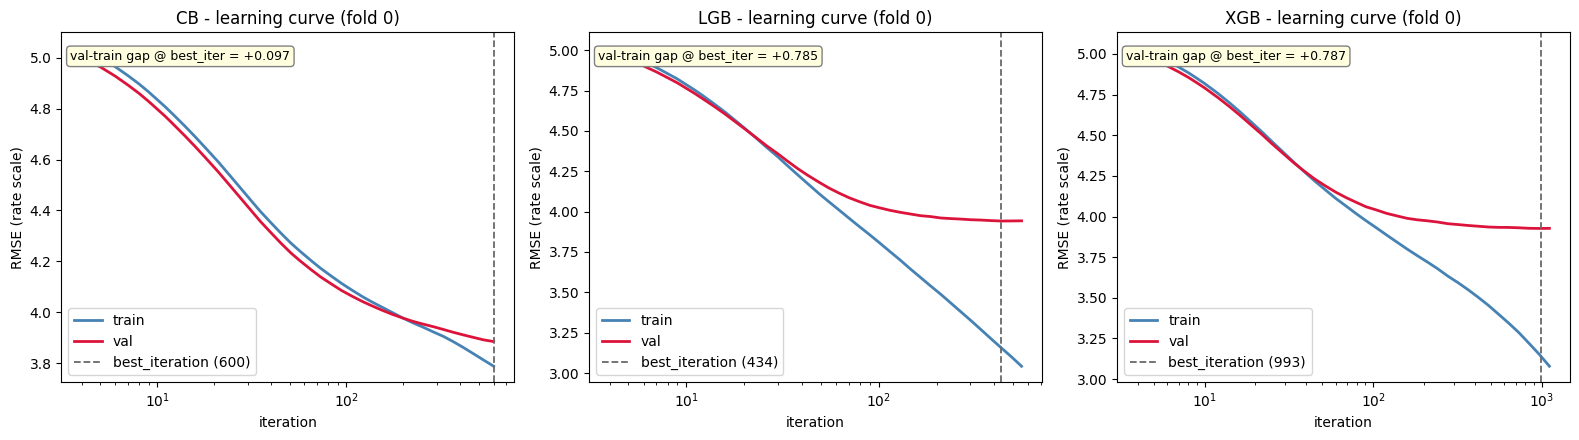

In [36]:
# Only the gradient-boosted trees have per-round curves; rf / ridge / mlp are
# not iterative learners, so we plot just the boosting bases.
tree_bases = [b for b in BASES if learning_curves[b]['iters']]
fig, axes = plt.subplots(1, len(tree_bases), figsize=(5.3 * len(tree_bases), 4.5),
                         squeeze=False)
axes = axes.flatten()
for i, b in enumerate(tree_bases):
    lc = learning_curves[b]
    iters = np.array(lc['iters'])
    axes[i].plot(iters, lc['train_rmse'], color='steelblue', label='train', linewidth=2)
    axes[i].plot(iters, lc['val_rmse'], color='crimson', label='val', linewidth=2)
    best_pos = lc['best_pos']
    axes[i].axvline(best_pos, color='dimgrey', linestyle='--', linewidth=1.3,
                    label='best_iteration (%d)' % (best_pos + 1))
    axes[i].set_xscale('log')
    axes[i].set_xlabel('iteration')
    axes[i].set_ylabel('RMSE (rate scale)')
    axes[i].set_title(b.upper() + ' - learning curve (fold 0)')
    axes[i].legend()
    gap_best = lc['best_val'] - lc['best_train']
    axes[i].text(0.02, 0.95, 'val-train gap @ best_iter = %+.3f' % gap_best,
                 transform=axes[i].transAxes, ha='left', va='top', fontsize=9,
                 bbox=dict(facecolor='lightyellow', edgecolor='grey', boxstyle='round'))
plt.tight_layout()
plt.savefig(OUT_DIR / 'final_diag_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## Plot 2 — sklearn `learning_curve` on CatBoost over training-set sizes

For a few training-set fractions we refit a smaller CatBoost and record train + CV RMSE.
Tells us whether more data would still help.

Reading guide:
* **CV RMSE still falling at 100%** → data-limited. Adding rows would reduce RMSE.
* **CV RMSE flat / rising at 100%** → capacity-limited. More data won't help; raise capacity instead.

First we build the full-train target-encoded CatBoost frames, which are shared by this
plot and the entire explainability suite in Part 3.

In [37]:
# Full-train TE frames - shared by Plot 2 and Part 3.
Xtr_te_full, Xval_te_full, Xte_te_full = fp.add_target_encodings(X_train, y_train, X_val, test_fe)
Xtr_cb_full, cat_idx_full = fp.to_catboost_pool(Xtr_te_full)
Xval_cb_full, _ = fp.to_catboost_pool(Xval_te_full)
Xte_cb_full, _ = fp.to_catboost_pool(Xte_te_full)
print('full-train CB frame:', Xtr_cb_full.shape)
print('categorical cols   :', [Xtr_cb_full.columns[i] for i in cat_idx_full])


full-train CB frame: (80000, 64)
categorical cols   : ['addr_state', 'application_type', 'verification_status', 'emp_title', 'home_ownership', 'zip3', 'purpose']


Computing sklearn learning_curve on CatBoost over training-set size...
  done in 513s


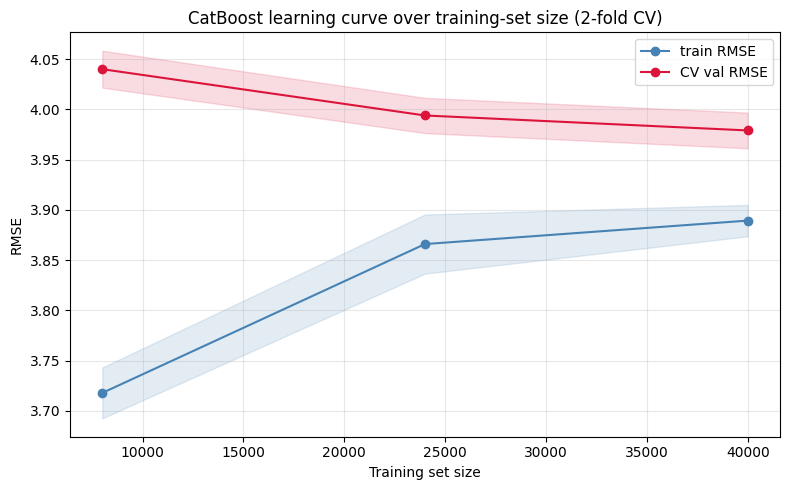


CV val RMSE slope between last two points: -0.000001 per row
  -> CV RMSE flat - capacity-saturated at this depth/iterations.


In [38]:
from sklearn.base import BaseEstimator, RegressorMixin

# Data-size-curve runtime knobs (raise for full-strength curves).
LC_SIZE_ITERS = 300
LC_SIZE_FRACTIONS = 3
LC_SIZE_CV = 2


class CatBoostFitShim(RegressorMixin, BaseEstimator):
    # Explicit constructor params (no **kwargs) so sklearn clone/get_params work:
    # sklearn silently drops VAR_KEYWORD params, and clone asserts each param is
    # stored verbatim, so we keep them unmodified and only transform inside fit().
    def __init__(self, cat_idx=None, columns=None, iterations=300,
                 learning_rate=0.03, depth=7, l2_leaf_reg=5.0,
                 loss_function='RMSE', eval_metric='RMSE'):
        self.cat_idx = cat_idx
        self.columns = columns
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.l2_leaf_reg = l2_leaf_reg
        self.loss_function = loss_function
        self.eval_metric = eval_metric

    def fit(self, X, y):
        self.model_ = CatBoostRegressor(
            iterations=self.iterations, learning_rate=self.learning_rate,
            depth=self.depth, l2_leaf_reg=self.l2_leaf_reg,
            loss_function=self.loss_function, eval_metric=self.eval_metric,
            random_seed=fp.RANDOM_STATE, verbose=0, allow_writing_files=False)
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=list(self.columns))
        else:
            X = X.copy()
        for i in self.cat_idx:
            c = X.columns[i]
            X[c] = X[c].astype('string').fillna('Missing')
        self.feat_cols_ = X.columns.tolist()
        self.model_.fit(X, y, cat_features=list(self.cat_idx), verbose=False)
        return self

    def predict(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feat_cols_)
        else:
            X = X.copy()
        for i in self.cat_idx:
            c = X.columns[i]
            X[c] = X[c].astype('string').fillna('Missing')
        return self.model_.predict(X)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = 'regressor'
        try:
            from sklearn.utils._tags import RegressorTags
            tags.regressor_tags = RegressorTags()
        except Exception:
            pass
        return tags


print('Computing sklearn learning_curve on CatBoost over training-set size...')
t = time()
shim_lc = CatBoostFitShim(cat_idx=cat_idx_full, columns=Xtr_cb_full.columns,
                          iterations=LC_SIZE_ITERS,
                          learning_rate=tuning['CatBoost'].get('learning_rate', 0.03),
                          depth=tuning['CatBoost'].get('depth', 7),
                          l2_leaf_reg=tuning['CatBoost'].get('l2_leaf_reg', 5.0),
                          loss_function='RMSE', eval_metric='RMSE')
train_sizes_abs, train_scores, val_scores = learning_curve(
    shim_lc, Xtr_cb_full, y_train,
    train_sizes=np.linspace(0.2, 1.0, LC_SIZE_FRACTIONS),
    cv=LC_SIZE_CV, scoring='neg_root_mean_squared_error', n_jobs=1,
    random_state=fp.RANDOM_STATE,
)
print('  done in %.0fs' % (time() - t))

train_rmse_mean = -train_scores.mean(axis=1); train_rmse_std = train_scores.std(axis=1)
val_rmse_mean = -val_scores.mean(axis=1); val_rmse_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_abs, train_rmse_mean, 'o-', color='steelblue', label='train RMSE')
plt.fill_between(train_sizes_abs, train_rmse_mean - train_rmse_std, train_rmse_mean + train_rmse_std, color='steelblue', alpha=0.15)
plt.plot(train_sizes_abs, val_rmse_mean, 'o-', color='crimson', label='CV val RMSE')
plt.fill_between(train_sizes_abs, val_rmse_mean - val_rmse_std, val_rmse_mean + val_rmse_std, color='crimson', alpha=0.15)
plt.xlabel('Training set size'); plt.ylabel('RMSE')
plt.title('CatBoost learning curve over training-set size (%d-fold CV)' % LC_SIZE_CV)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUT_DIR / 'final_diag_learning_curve_size.png', dpi=120, bbox_inches='tight')
plt.show()

slope = (val_rmse_mean[-1] - val_rmse_mean[-2]) / (train_sizes_abs[-1] - train_sizes_abs[-2])
print()
print('CV val RMSE slope between last two points: %.6f per row' % slope)
if slope < -1e-5:
    print('  -> CV RMSE still falling - more data would help.')
elif slope > 1e-5:
    print('  -> CV RMSE rising - capacity-limited, more data will not help.')
else:
    print('  -> CV RMSE flat - capacity-saturated at this depth/iterations.')


## Plot 3 — OOF-vs-val residual distribution overlay

If OOF and val residuals share the same distribution, the model generalises consistently
across the CV folds and the held-out 20%. If they diverge (val tails fatter), the blend
is overfitting the OOF folds and val RMSE is an unreliable test-RMSE estimate.

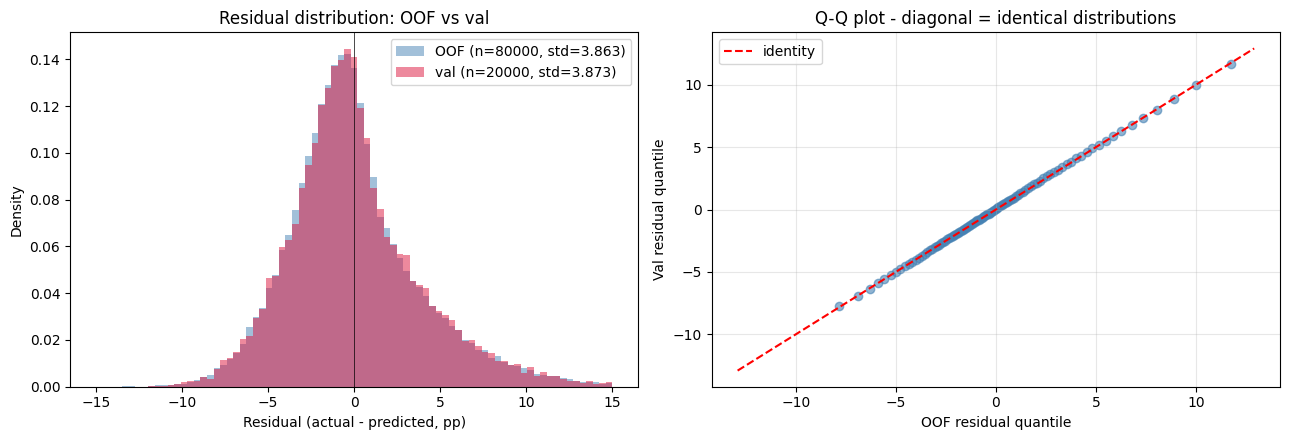


|std(OOF) - std(val)| = 0.0098
  -> Distributions match closely. Cross-fold generalisation looks healthy.


In [39]:
resid_oof = y_train - oof_blend
resid_val = y_val   - val_blend

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.linspace(-15, 15, 80)
axes[0].hist(resid_oof, bins=bins, alpha=0.5, color='steelblue', density=True,
             label='OOF (n=%d, std=%.3f)' % (len(resid_oof), resid_oof.std()))
axes[0].hist(resid_val, bins=bins, alpha=0.5, color='crimson', density=True,
             label='val (n=%d, std=%.3f)' % (len(resid_val), resid_val.std()))
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Residual (actual - predicted, pp)')
axes[0].set_ylabel('Density')
axes[0].set_title('Residual distribution: OOF vs val')
axes[0].legend()

oof_q = np.quantile(resid_oof, np.linspace(0.01, 0.99, 100))
val_q = np.quantile(resid_val, np.linspace(0.01, 0.99, 100))
axes[1].scatter(oof_q, val_q, alpha=0.6, color='steelblue')
lim = max(abs(oof_q).max(), abs(val_q).max()) * 1.1
axes[1].plot([-lim, lim], [-lim, lim], 'r--', label='identity')
axes[1].set_xlabel('OOF residual quantile')
axes[1].set_ylabel('Val residual quantile')
axes[1].set_title('Q-Q plot - diagonal = identical distributions')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'final_diag_resid_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

ks_diff = abs(np.std(resid_oof) - np.std(resid_val))
print()
print('|std(OOF) - std(val)| = %.4f' % ks_diff)
if ks_diff < 0.1:
    print('  -> Distributions match closely. Cross-fold generalisation looks healthy.')
elif ks_diff < 0.3:
    print('  -> Mild divergence. Worth checking on a second seed.')
else:
    print('  -> Significant divergence - OOF and val tell different stories. Investigate.')


## Plot 4 — Per-fold OOF RMSE bar chart

One bar per base learner per fold, reconstructed from the cached OOF predictions by
re-deriving the pipeline's K-fold split (same seed). Low fold-to-fold variance means
stable generalisation; high variance is a leak / distribution-shift / instability signal.

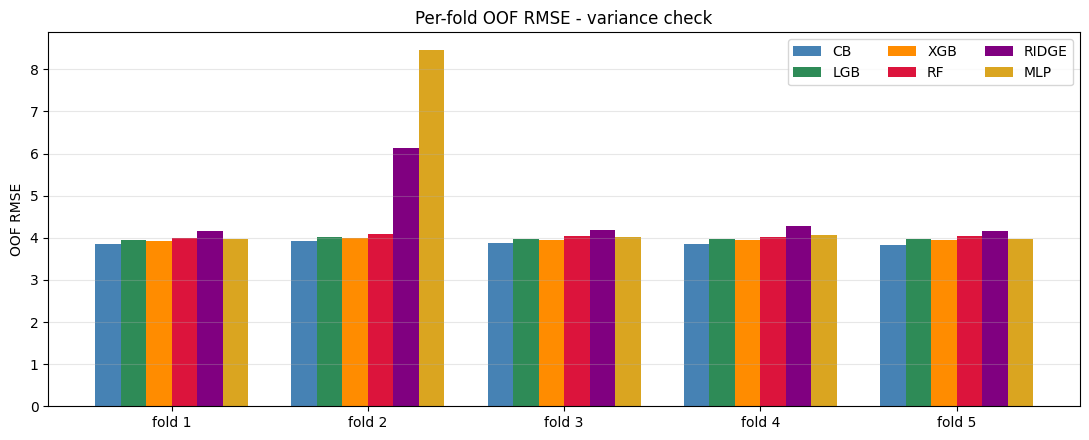


Fold-to-fold stability (std / mean):
  CB   : mean=3.8633  std=0.0318  CV=0.82%
  LGB  : mean=3.9734  std=0.0285  CV=0.72%
  XGB  : mean=3.9532  std=0.0265  CV=0.67%
  RF   : mean=4.0371  std=0.0306  CV=0.76%
  RIDGE: mean=4.5846  std=0.8683  CV=18.94%
  MLP  : mean=4.8997  std=1.9880  CV=40.57%


In [40]:
kf = KFold(n_splits=fp.N_FOLDS, shuffle=True, random_state=fp.RANDOM_STATE)
fold_rmses = []
for fold_id, (tr_i, va_i) in enumerate(kf.split(X_train)):
    row = {}
    for i, b in enumerate(BASES):
        row[b] = float(np.sqrt(mean_squared_error(y_train[va_i], stack_tr[va_i, i])))
    fold_rmses.append(row)
fold_df = pd.DataFrame(fold_rmses)

fig, ax = plt.subplots(figsize=(11, 4.5))
n_folds_actual = len(fold_df)
bar_w = 0.13
x = np.arange(n_folds_actual)
palette = {'cb': 'steelblue', 'lgb': 'seagreen', 'xgb': 'darkorange',
           'rf': 'crimson', 'ridge': 'purple', 'mlp': 'goldenrod'}
for i, b in enumerate(BASES):
    ax.bar(x + i * bar_w, fold_df[b].values, width=bar_w, label=b.upper(),
           color=palette.get(b, 'grey'))
ax.set_xticks(x + (len(BASES) - 1) / 2 * bar_w)
ax.set_xticklabels(['fold %d' % (i + 1) for i in range(n_folds_actual)])
ax.set_ylabel('OOF RMSE')
ax.set_title('Per-fold OOF RMSE - variance check')
ax.legend(ncol=3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'final_diag_fold_rmse.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print('Fold-to-fold stability (std / mean):')
for b in BASES:
    cv = fold_df[b].std() / fold_df[b].mean()
    print('  %-5s: mean=%.4f  std=%.4f  CV=%.2f%%' % (b.upper(), fold_df[b].mean(), fold_df[b].std(), 100 * cv))


---
# Part 3 — Explainability (run live, W2 style)

Global (permutation, gain, SHAP) → local (PDP, ICE, waterfall, LIME) → cross-split SHAP.
Re-fits a single CatBoost on the full 80% training fold (using the cached tuning params
and the full-train TE frames from Part 2) for clean explanations.

In [41]:
# Explainability config (raise for full-strength explanations).
PERM_N_REPEATS = 3
SHAP_SAMPLE_SIZE = 800
SHAP_SPLIT_SAMPLE = 500
EXPLAIN_CB_ITERS = 1200

explain_model = CatBoostRegressor(**tuning['CatBoost'], iterations=EXPLAIN_CB_ITERS,
                                  loss_function='RMSE', eval_metric='RMSE',
                                  random_seed=fp.RANDOM_STATE, verbose=0,
                                  allow_writing_files=False, early_stopping_rounds=100)
explain_model.fit(Xtr_cb_full, y_train, cat_features=cat_idx_full,
                  eval_set=(Xval_cb_full, y_val), verbose=False)
explain_val_rmse = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xval_cb_full))))
print('Explainability CB val_RMSE: %.4f  (trees: %d)' % (explain_val_rmse, explain_model.tree_count_))


Explainability CB val_RMSE: 3.8878  (trees: 1199)


## 12. Permutation importance (validation set)

Each feature is shuffled `PERM_N_REPEATS` times and the mean increase in validation RMSE
is recorded; larger increases indicate more influential features.

Computing permutation importance (n_repeats=3)...
  done in 35s


,feature,perm_mean,perm_std
0,fico,0.427958,0.011014
1,term_months,0.253692,0.005813
2,fico_band,0.150858,0.005366
3,term_x_dti,0.124086,0.005692
4,loan_amnt,0.114517,0.002347
5,purpose,0.104378,0.003359
6,mths_since_rcnt_il,0.095235,0.000909
7,application_type,0.056724,0.001210
8,all_util,0.053988,0.001556
9,dti,0.040415,0.002788


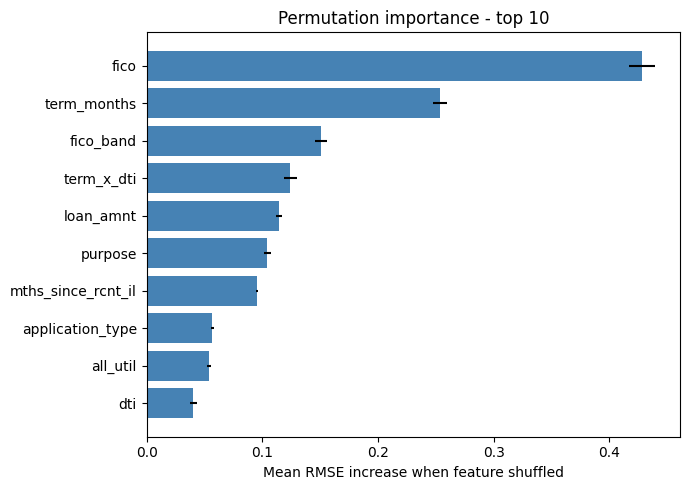

In [42]:
print('Computing permutation importance (n_repeats=%d)...' % PERM_N_REPEATS)
t = time()
rng = np.random.default_rng(fp.RANDOM_STATE)
baseline_rmse = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xval_cb_full))))
perm_records = []
for col in Xval_cb_full.columns:
    drops = []
    for r in range(PERM_N_REPEATS):
        Xp = Xval_cb_full.copy()
        Xp[col] = Xp[col].sample(frac=1.0, random_state=int(rng.integers(0, 1_000_000))).values
        rmse_perm = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xp))))
        drops.append(rmse_perm - baseline_rmse)
    perm_records.append({'feature': col, 'perm_mean': float(np.mean(drops)), 'perm_std': float(np.std(drops))})
perm_df = pd.DataFrame(perm_records).sort_values('perm_mean', ascending=False).reset_index(drop=True)
print('  done in %.0fs' % (time() - t))
display(perm_df.head(15))

plt.figure(figsize=(7, 5))
top10 = perm_df.head(10)
plt.barh(top10['feature'][::-1], top10['perm_mean'][::-1], xerr=top10['perm_std'][::-1], color='steelblue')
plt.xlabel('Mean RMSE increase when feature shuffled')
plt.title('Permutation importance - top 10')
plt.tight_layout()
plt.savefig(OUT_DIR / 'final_perm_top10.png', dpi=120, bbox_inches='tight')
plt.show()
perm_df.to_csv(OUT_DIR / 'final_perm_importance.csv', index=False)


## 13. CatBoost native gain importance

,feature,gain,gain_share
0,fico,15.221313,0.152213
1,fico_band,8.769427,0.087694
2,term_months,6.916360,0.069164
3,term_x_dti,6.025185,0.060252
4,loan_amnt,4.635334,0.046353
5,purpose,4.529691,0.045297
6,mths_since_rcnt_il,4.093091,0.040931
7,all_util,3.746952,0.037470
8,dti,2.544058,0.025441
9,application_type,2.442812,0.024428


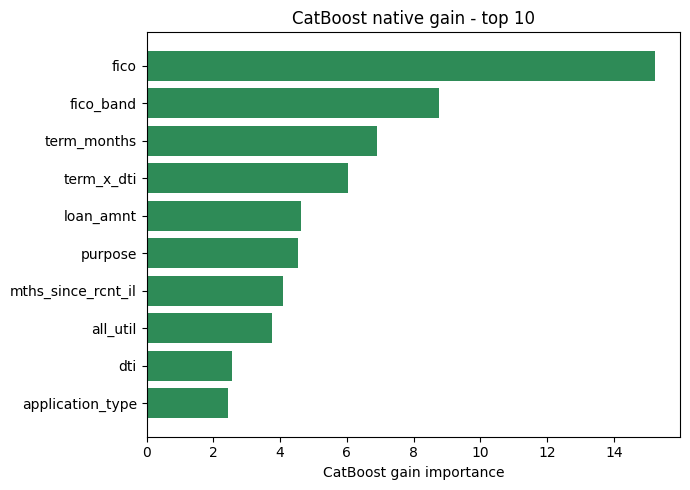

In [43]:
native_imp = pd.DataFrame({
    'feature': Xtr_cb_full.columns,
    'gain': explain_model.get_feature_importance(),
}).sort_values('gain', ascending=False).reset_index(drop=True)
native_imp['gain_share'] = native_imp['gain'] / native_imp['gain'].sum()
display(native_imp.head(15))

plt.figure(figsize=(7, 5))
top10 = native_imp.head(10)
plt.barh(top10['feature'][::-1], top10['gain'][::-1], color='seagreen')
plt.xlabel('CatBoost gain importance')
plt.title('CatBoost native gain - top 10')
plt.tight_layout()
plt.savefig(OUT_DIR / 'final_cb_gain_top10.png', dpi=120, bbox_inches='tight')
plt.show()
native_imp.to_csv(OUT_DIR / 'final_cb_gain.csv', index=False)


## 14. SHAP — summary and dependence on top features

Computing native CatBoost SHAP on val set...
SHAP shape: (800, 64)  expected: 12.930  (4s)


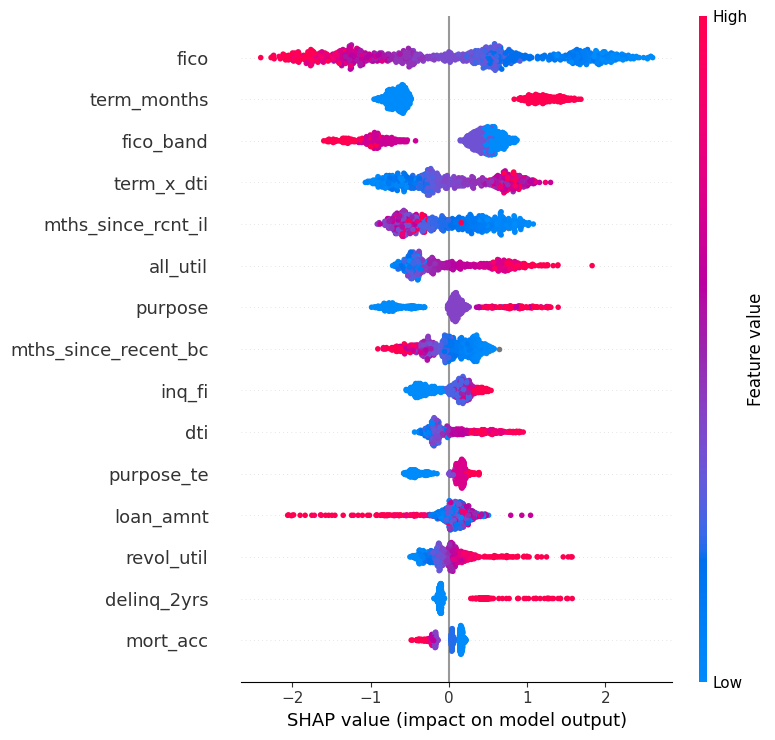

In [44]:
import shap


def cb_to_numeric(df_cb):
    out = df_cb.copy()
    for i in cat_idx_full:
        col = out.columns[i]
        codes, _ = pd.factorize(out[col].astype('string').fillna('Missing'))
        out[col] = codes.astype('int64')
    return out


shap_sample_size = min(SHAP_SAMPLE_SIZE, len(Xval_cb_full))
shap_idx = np.random.default_rng(fp.RANDOM_STATE).choice(len(Xval_cb_full), size=shap_sample_size, replace=False)
Xval_shap_sample = Xval_cb_full.iloc[shap_idx].reset_index(drop=True)

print('Computing native CatBoost SHAP on val set...')
t = time()
pool_val = Pool(Xval_shap_sample, cat_features=cat_idx_full)
shap_with_expected = explain_model.get_feature_importance(pool_val, type='ShapValues')
expected_value = float(shap_with_expected[0, -1])
shap_values_val = shap_with_expected[:, :-1]
print('SHAP shape: %s  expected: %.3f  (%.0fs)' % (str(shap_values_val.shape), expected_value, time() - t))

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values_val, cb_to_numeric(Xval_shap_sample),
                  feature_names=list(Xval_shap_sample.columns), max_display=15, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR / 'final_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()


Top 5 by mean |SHAP|: ['fico', 'term_months', 'fico_band', 'term_x_dti', 'mths_since_rcnt_il']


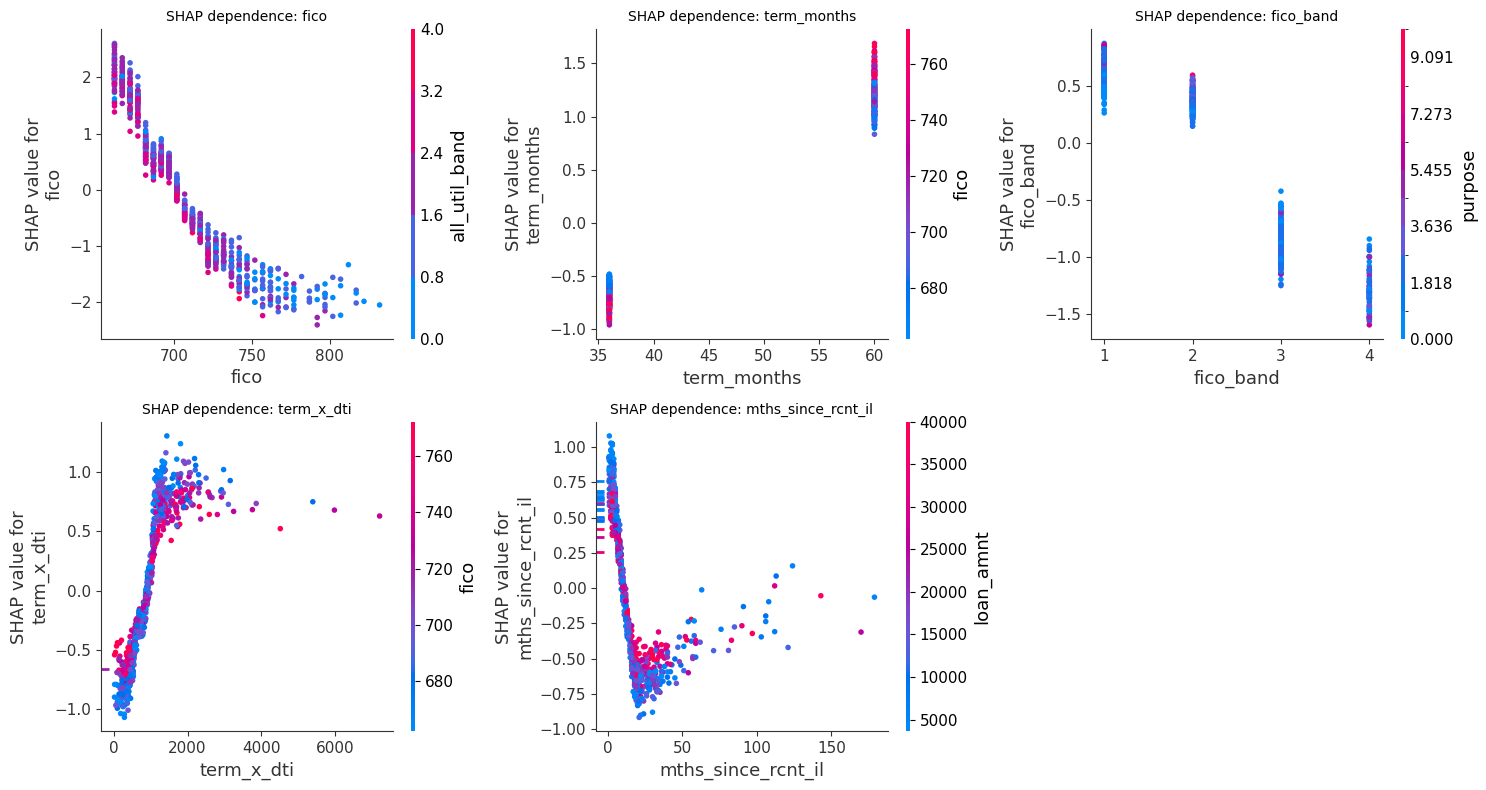

In [45]:
mean_abs_shap = np.abs(shap_values_val).mean(axis=0)
shap_ranking = pd.Series(mean_abs_shap, index=Xval_shap_sample.columns).sort_values(ascending=False)
top5_shap = shap_ranking.head(5).index.tolist()
print('Top 5 by mean |SHAP|:', top5_shap)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
Xval_shap_numeric_sample = cb_to_numeric(Xval_shap_sample)
for i, feat in enumerate(top5_shap):
    shap.dependence_plot(feat, shap_values_val, Xval_shap_numeric_sample,
                         feature_names=list(Xval_shap_sample.columns),
                         ax=axes[i], show=False, interaction_index='auto')
    axes[i].set_title('SHAP dependence: ' + feat, fontsize=10)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'final_shap_dependence_top5.png', dpi=120, bbox_inches='tight')
plt.show()


## 15. Partial dependence and ICE — top numeric features

PDP features: ['fico', 'term_months', 'fico_band']


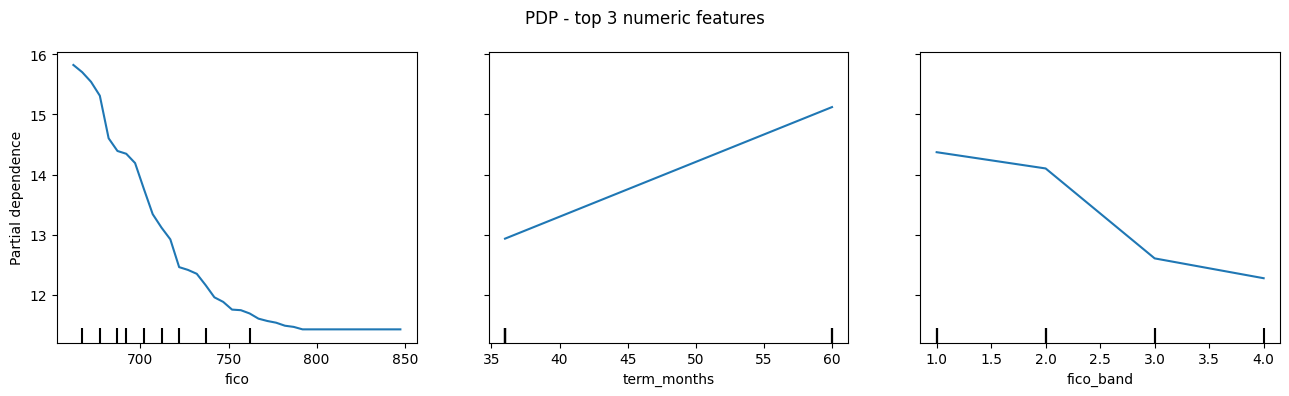

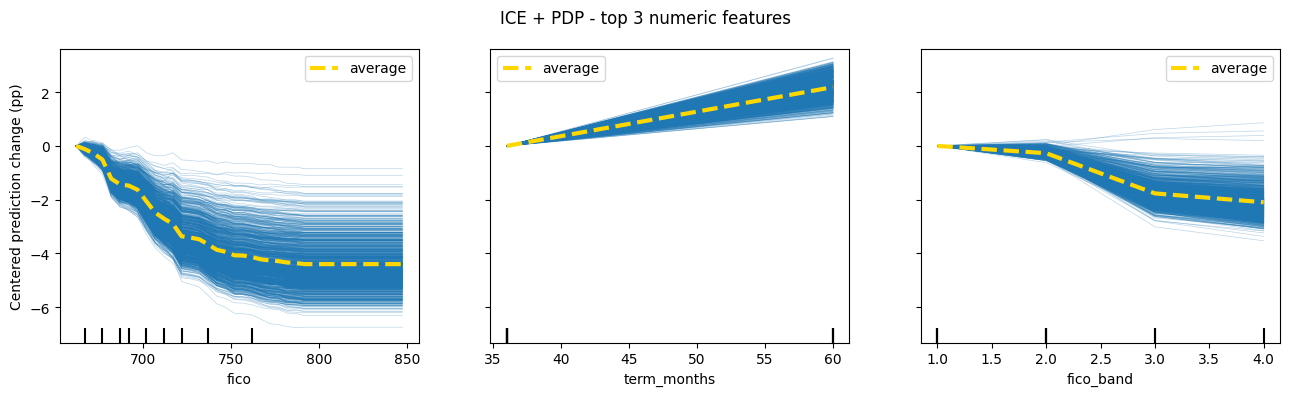

In [46]:
from sklearn.inspection import PartialDependenceDisplay


class CatBoostShim(RegressorMixin, BaseEstimator):
    def __init__(self, model, columns, cat_idx):
        self.model = model
        self.columns = list(columns)
        self.cat_idx = list(cat_idx)
        self.n_features_in_ = len(self.columns)
        self.feature_names_in_ = np.array(self.columns, dtype=object)
        self.is_fitted_ = True

    def __sklearn_is_fitted__(self):
        return True

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = 'regressor'
        try:
            from sklearn.utils._tags import RegressorTags
            tags.regressor_tags = RegressorTags()
        except Exception:
            pass
        return tags

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        df = pd.DataFrame(X, columns=self.columns)
        for i in self.cat_idx:
            c = self.columns[i]
            df[c] = df[c].astype('string').fillna('Missing')
        for j, c in enumerate(self.columns):
            if j not in self.cat_idx:
                df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
        return self.model.predict(df)


shim_pdp = CatBoostShim(explain_model, Xval_cb_full.columns, cat_idx_full)
Xtr_pdp_numeric = cb_to_numeric(Xtr_cb_full).values
numeric_cols_for_pdp = [c for j, c in enumerate(Xtr_cb_full.columns) if j not in cat_idx_full]
top3_perm_numeric = [f for f in perm_df['feature'] if f in numeric_cols_for_pdp][:3]
print('PDP features:', top3_perm_numeric)

fig, ax = plt.subplots(figsize=(13, 4))
PartialDependenceDisplay.from_estimator(
    shim_pdp, Xtr_pdp_numeric,
    features=[list(Xtr_cb_full.columns).index(f) for f in top3_perm_numeric],
    feature_names=list(Xtr_cb_full.columns), ax=ax, kind='average')
plt.suptitle('PDP - top 3 numeric features')
plt.tight_layout()
plt.savefig(OUT_DIR / 'final_pdp_top3.png', dpi=120, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
display_ice = PartialDependenceDisplay.from_estimator(
    shim_pdp, Xtr_pdp_numeric,
    features=[list(Xtr_cb_full.columns).index(f) for f in top3_perm_numeric],
    feature_names=list(Xtr_cb_full.columns), kind='both', centered=True, ax=ax,
    pd_line_kw={'color': 'gold', 'linewidth': 3})
display_ice.axes_[0, 0].set_ylabel('Centered prediction change (pp)')
plt.suptitle('ICE + PDP - top 3 numeric features')
plt.tight_layout()
plt.savefig(OUT_DIR / 'final_ice_top3.png', dpi=120, bbox_inches='tight')
plt.show()


## 16. Representative rows — SHAP waterfall and LIME

Low / median / high predicted-rate rows from the chosen blend, explained two ways.

Representative rows:
  low rate (5th pct)     idx=6137  predicted=7.30%  actual=7.02%
  median rate            idx=8052  predicted=12.86%  actual=8.81%
  high rate (95th pct)   idx=16918  predicted=18.99%  actual=17.74%


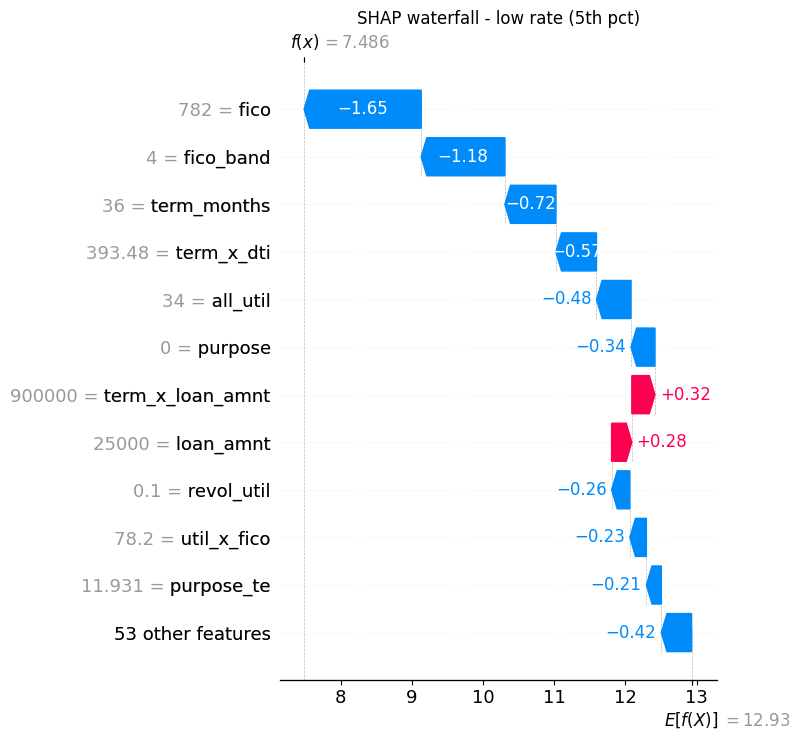

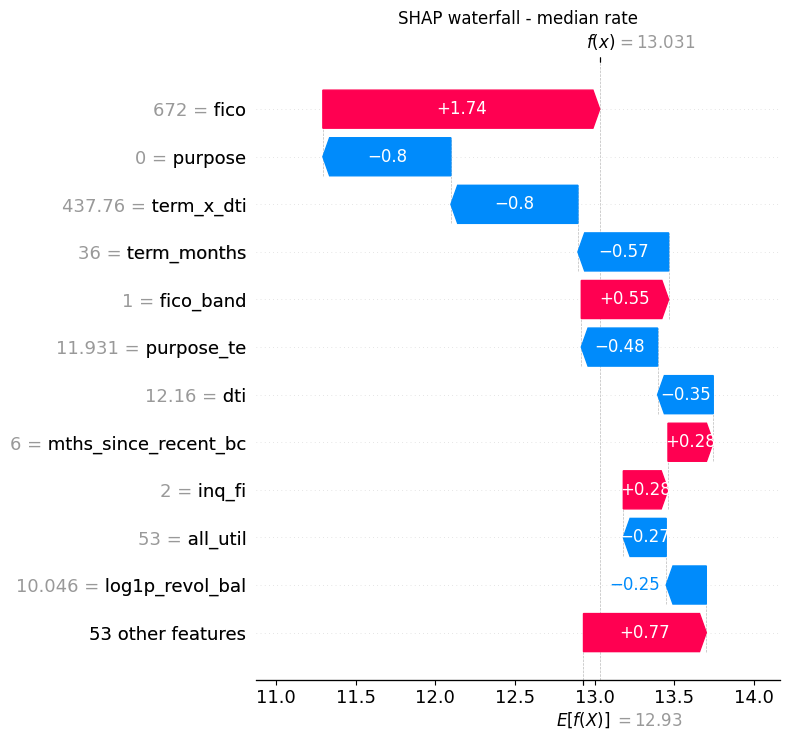

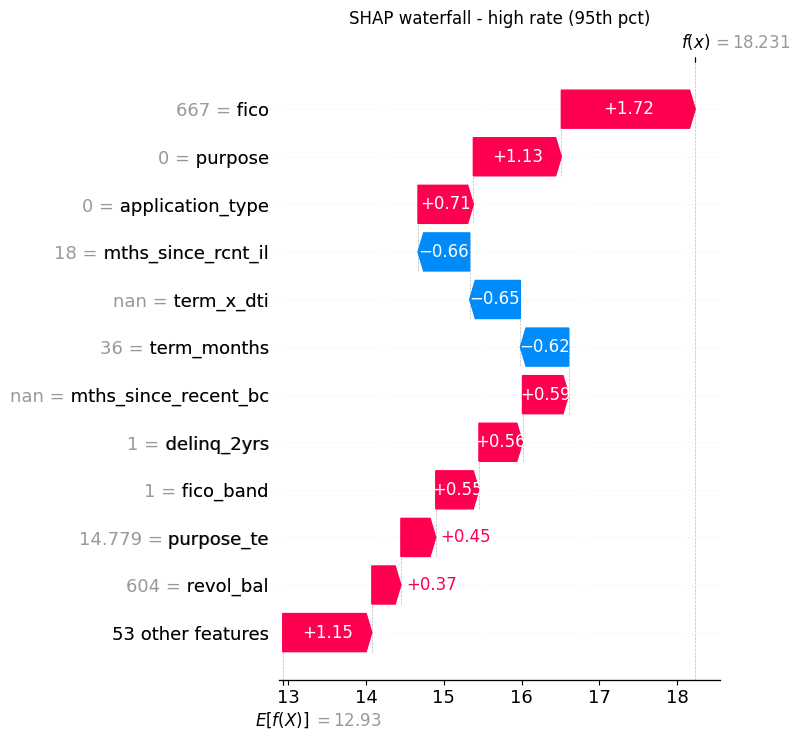

In [47]:
val_preds = val_blend
order = np.argsort(val_preds)
rep_indices = {
    'low rate (5th pct)':   int(order[int(0.05 * len(order))]),
    'median rate':          int(order[len(order) // 2]),
    'high rate (95th pct)': int(order[int(0.95 * len(order))]),
}
print('Representative rows:')
for label, idx in rep_indices.items():
    print('  %-22s idx=%d  predicted=%.2f%%  actual=%.2f%%' % (label, idx, val_preds[idx], y_val[idx]))

for label, idx in rep_indices.items():
    instance_row = Xval_cb_full.iloc[[idx]].reset_index(drop=True)
    pool_inst = Pool(instance_row, cat_features=cat_idx_full)
    shap_with_exp = explain_model.get_feature_importance(pool_inst, type='ShapValues')
    expected = float(shap_with_exp[0, -1])
    shap_values_inst = shap_with_exp[:, :-1]
    instance_dense = cb_to_numeric(instance_row).iloc[0].values
    plt.figure()
    shap.plots.waterfall(
        shap.Explanation(values=shap_values_inst[0], base_values=expected,
                         data=instance_dense, feature_names=list(instance_row.columns)),
        max_display=12, show=False)
    plt.title('SHAP waterfall - ' + label)
    plt.tight_layout()
    plt.savefig(OUT_DIR / ('final_shap_waterfall_' + label.split()[0] + '.png'), dpi=120, bbox_inches='tight')
    plt.show()



--- LIME: low rate (5th pct)  (predicted 7.30%, actual 7.02%) ---


,feature,weight
0,fico,-1.235790
1,purpose=0,-0.866294
2,term_months,0.746489
3,fico_band,-0.681508
4,term_x_dti,0.633997
5,all_util,0.396837
6,revol_util,0.266422
7,purpose_te,0.228461
8,emp_title=30,0.186132
9,util_x_fico,0.145475


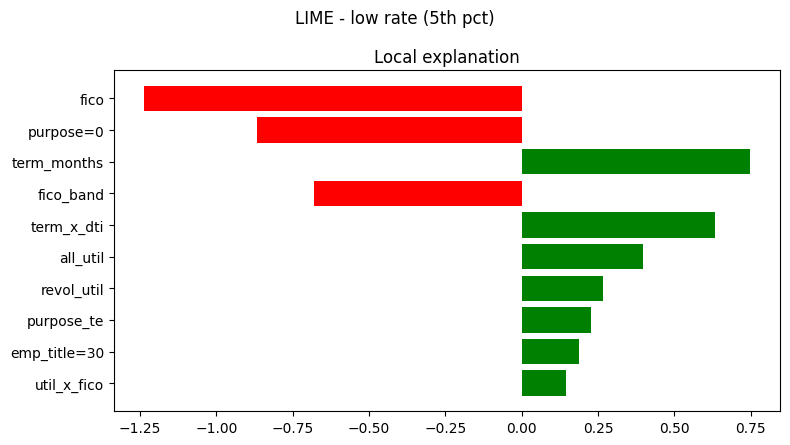


--- LIME: median rate  (predicted 12.86%, actual 8.81%) ---


,feature,weight
0,fico,-1.271296
1,purpose=0,-0.892115
2,term_months,0.737908
3,fico_band,-0.631038
4,term_x_dti,0.626204
5,zip3=19,-0.588102
6,mths_since_recent_bc,-0.353625
7,revol_util,0.263961
8,purpose_te,0.170454
9,verification_status=0,-0.153370


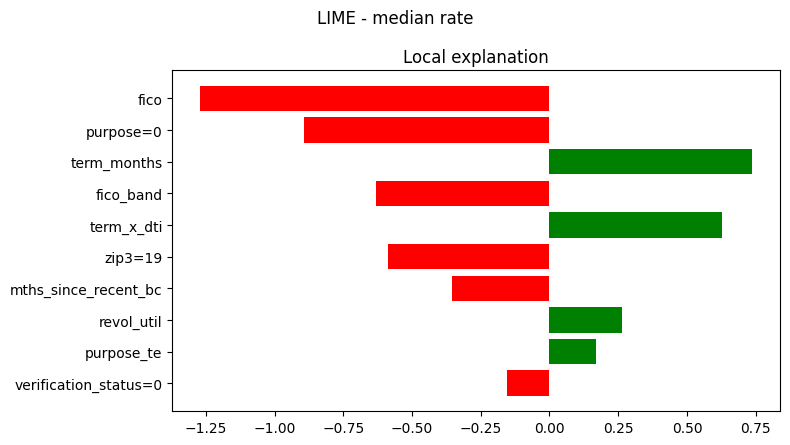


--- LIME: high rate (95th pct)  (predicted 18.99%, actual 17.74%) ---


,feature,weight
0,fico,-1.229173
1,term_months,0.709650
2,fico_band,-0.657688
3,delinq_2yrs,0.200514
4,mths_since_recent_inq,-0.167414
5,purpose_te,0.160024
6,log1p_revol_bal,-0.091443
7,log1p_annual_inc,-0.075051
8,purpose=10,0.050095
9,zip3=759,-0.007346


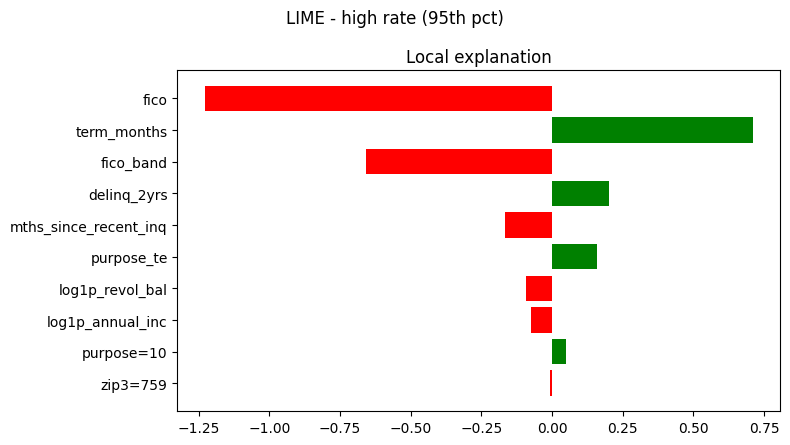

In [48]:
import lime
import lime.lime_tabular

cat_code_maps = {}
cat_train_arrays = {}
for i in cat_idx_full:
    col = Xtr_cb_full.columns[i]
    series_str = Xtr_cb_full[col].astype('string').fillna('Missing')
    codes, uniques = pd.factorize(series_str)
    cat_code_maps[col] = {idx: val for idx, val in enumerate(uniques)}
    cat_train_arrays[col] = codes

Xtr_lime = Xtr_cb_full.copy()
for i in cat_idx_full:
    col = Xtr_cb_full.columns[i]
    Xtr_lime[col] = cat_train_arrays[col]
for j, c in enumerate(Xtr_lime.columns):
    if j not in cat_idx_full:
        Xtr_lime[c] = pd.to_numeric(Xtr_lime[c], errors='coerce').astype('float64')
Xtr_lime_np = Xtr_lime.values.astype('float64')

lime_fill = np.nanmean(Xtr_lime_np, axis=0)
lime_fill = np.where(np.isnan(lime_fill), 0.0, lime_fill)
inds = np.where(np.isnan(Xtr_lime_np))
Xtr_lime_np[inds] = np.take(lime_fill, inds[1])

Xval_lime = Xval_cb_full.copy()
for i in cat_idx_full:
    col = Xval_cb_full.columns[i]
    series_str = Xval_cb_full[col].astype('string').fillna('Missing')
    inv = {v: k for k, v in cat_code_maps[col].items()}
    next_code = max(cat_code_maps[col].keys()) + 1 if cat_code_maps[col] else 0
    Xval_lime[col] = series_str.map(lambda v: inv.get(v, next_code)).astype('int64')
for j, c in enumerate(Xval_lime.columns):
    if j not in cat_idx_full:
        Xval_lime[c] = pd.to_numeric(Xval_lime[c], errors='coerce').astype('float64')
Xval_lime_np = Xval_lime.values.astype('float64')
inds = np.where(np.isnan(Xval_lime_np))
Xval_lime_np[inds] = np.take(lime_fill, inds[1])

lime_categorical_features = [list(Xtr_cb_full.columns).index(c)
                             for c in fp.ALL_CAT_COLS if c in Xtr_cb_full.columns]
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=Xtr_lime_np,
    feature_names=list(Xtr_cb_full.columns),
    categorical_features=lime_categorical_features,
    mode='regression',
    random_state=fp.RANDOM_STATE,
    discretize_continuous=False,
)


def cb_predict_numeric(X_np):
    df = pd.DataFrame(X_np, columns=Xtr_cb_full.columns)
    for i in cat_idx_full:
        col = Xtr_cb_full.columns[i]
        mapping = cat_code_maps[col]
        codes_int = df[col].round().astype('Int64')
        df[col] = codes_int.apply(lambda v: mapping.get(int(v), 'Missing') if pd.notna(v) else 'Missing').astype('string')
    for j, c in enumerate(df.columns):
        if j not in cat_idx_full:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return explain_model.predict(df)


for label, idx in rep_indices.items():
    instance_np = Xval_lime_np[idx]
    print()
    print('--- LIME: %s  (predicted %.2f%%, actual %.2f%%) ---' % (label, val_preds[idx], y_val[idx]))
    explanation = lime_explainer.explain_instance(instance_np, cb_predict_numeric, num_features=10)
    lime_rows = pd.DataFrame(explanation.as_list(), columns=['feature', 'weight'])
    display(lime_rows)
    fig = explanation.as_pyplot_figure()
    fig.set_size_inches(8, 4.5)
    fig.suptitle('LIME - ' + label)
    plt.tight_layout()
    fig.savefig(OUT_DIR / ('final_lime_' + label.split()[0] + '.png'), dpi=120, bbox_inches='tight')
    plt.show()


## 17. Cross-split SHAP — train vs validation vs test

Mean |SHAP| per feature on each split. Large train→test drift on a top feature is a
distribution-shift warning.

,feature,mean_abs_train,mean_abs_val,mean_abs_test
0,fico,1.107,1.154,1.128
1,term_months,0.850,0.832,0.802
2,fico_band,0.646,0.661,0.711
3,term_x_dti,0.524,0.518,0.486
4,all_util,0.473,0.480,0.440
5,mths_since_rcnt_il,0.447,0.469,0.449
6,purpose,0.390,0.368,0.380
7,mths_since_recent_bc,0.261,0.270,0.237
8,inq_fi,0.240,0.235,0.217
9,revol_util,0.223,0.225,0.193


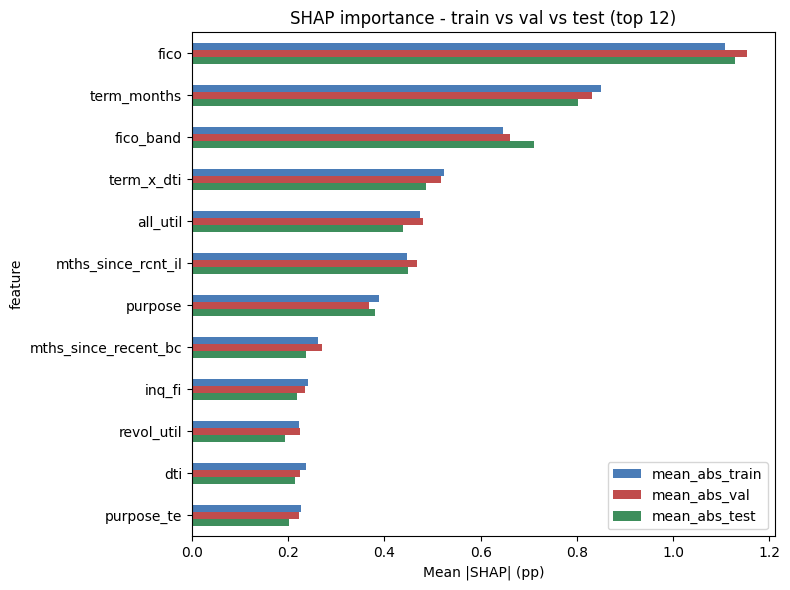

In [49]:
def _native_shap(df_subset):
    pool = Pool(df_subset, cat_features=cat_idx_full)
    arr = explain_model.get_feature_importance(pool, type='ShapValues')
    return arr[:, :-1]


SAMPLE = SHAP_SPLIT_SAMPLE
rng = np.random.default_rng(fp.RANDOM_STATE)
oof_idx_sub  = rng.choice(len(Xtr_cb_full), size=min(SAMPLE, len(Xtr_cb_full)), replace=False)
val_idx_sub  = rng.choice(len(Xval_cb_full), size=min(SAMPLE, len(Xval_cb_full)), replace=False)
test_idx_sub = rng.choice(len(Xte_cb_full), size=min(SAMPLE, len(Xte_cb_full)), replace=False)
shap_train = _native_shap(Xtr_cb_full.iloc[oof_idx_sub].reset_index(drop=True))
shap_val   = _native_shap(Xval_cb_full.iloc[val_idx_sub].reset_index(drop=True))
shap_test  = _native_shap(Xte_cb_full.iloc[test_idx_sub].reset_index(drop=True))

shap_compare = pd.DataFrame({
    'feature':        Xval_cb_full.columns,
    'mean_abs_train': np.abs(shap_train).mean(axis=0),
    'mean_abs_val':   np.abs(shap_val).mean(axis=0),
    'mean_abs_test':  np.abs(shap_test).mean(axis=0),
}).sort_values('mean_abs_val', ascending=False).reset_index(drop=True)
display(shap_compare.head(15).style.format({
    'mean_abs_train': '{:.3f}', 'mean_abs_val': '{:.3f}', 'mean_abs_test': '{:.3f}',
}))
shap_compare.to_csv(OUT_DIR / 'final_shap_meanabs_by_split.csv', index=False)

top_feats = shap_compare.head(12)['feature'].tolist()
top_df = shap_compare.set_index('feature').loc[top_feats][['mean_abs_train', 'mean_abs_val', 'mean_abs_test']]
ax = top_df.plot(kind='barh', figsize=(8, 6), color=['#4A7CB7', '#C04C4C', '#3E8E5C'])
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP| (pp)')
ax.set_title('SHAP importance - train vs val vs test (top 12)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'final_shap_meanabs_by_split.png', dpi=120, bbox_inches='tight')
plt.show()


## 18. Summary

**Part 1** loads the cached six-learner stacked ensemble and reports its held-out RMSE,
model-comparison chart, residual diagnostics, and submission file.

**Part 2** adds the V2 diagnostic suite (live): per-base learning curves, a CatBoost
data-size curve, the OOF-vs-val residual overlay, and a per-fold OOF RMSE variance check.

**Part 3** adds the V2 explainability suite (live): permutation importance, CatBoost
native gain, SHAP summary / dependence, PDP / ICE, SHAP waterfall, LIME, and cross-split
SHAP — all on a CatBoost refit on the full 80% training fold.

**Outputs written to `outputs/final/`:** `final_test_predictions.csv`,
`final_model_comparison.png`, `final_residuals.png`, `final_diag_*.png`,
`final_perm_*`, `final_cb_gain_*`, `final_shap_*`, `final_pdp_top3.png`,
`final_ice_top3.png`, `final_lime_*.png`.

To refresh the cached ensemble, re-run `.venv/Scripts/python.exe final/final_pipeline.py`.
